# 의사 결정 트리(decision tree)
```의사결정나무는 분석 결과를 해석하기 쉬우며, 변수 간의 상호작용과 비선형성을 반영하여 정확한 예측이 가능하다는 장점이 있다. 또한 모델의 직관성과 가시성이 높아, 어떤 결정에 대한 이유를 설명하기 용이하다는 특징이 있다.```

- 앙상블(다수의 결정 트리를 묶어서 처리)구조는 매우 성능이 좋다
- Kaggle의 대부분의 문제 해결에 강력한 성능을 발휘한다
- feature의 정규화를 하지 않는다

In [1]:
import pandas as pd

wine = pd.read_csv('wine.csv')
wine

,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0
...,...,...,...,...
6492,11.2,1.6,3.27,1.0
6493,9.6,8.0,3.15,1.0
6494,9.4,1.2,2.99,1.0
6495,12.8,1.1,3.34,1.0


In [2]:
wine.head()

,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0


In [3]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alcohol  6497 non-null   float64
 1   sugar    6497 non-null   float64
 2   pH       6497 non-null   float64
 3   class    6497 non-null   float64
dtypes: float64(4)
memory usage: 203.2 KB


In [4]:
wine.describe()

,alcohol,sugar,pH,class
count,6497.000000,6497.000000,6497.000000,6497.000000
mean,10.491801,5.443235,3.218501,0.753886
std,1.192712,4.757804,0.160787,0.430779
min,8.000000,0.600000,2.720000,0.000000
25%,9.500000,1.800000,3.110000,1.000000
50%,10.300000,3.000000,3.210000,1.000000
75%,11.300000,8.100000,3.320000,1.000000
max,14.900000,65.800000,4.010000,1.000000


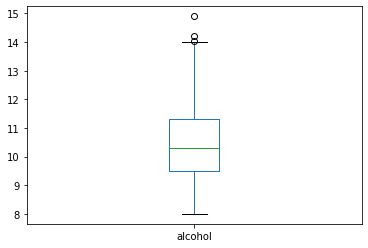

In [5]:
wine['alcohol'].plot(kind='box')

In [6]:
data = wine[['alcohol', 'sugar', 'pH']].to_numpy()
target = wine['class'].to_numpy()

print(data.shape)
print(target.shape)

(6497, 3)
(6497,)


In [7]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = \
    train_test_split(data, target, test_size=0.2, random_state=42)

print(train_input.shape)
print(test_input.shape)

(5197, 3)
(1300, 3)


In [8]:
# 로지스틱 회귀로 학습시키기 위해 정규화를 한다
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [10]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

0.7808350971714451
0.7776923076923077


## 로지스틱 회귀의 계수는 feature와 곱해진다
## 그런데, 이 계수가 어떤 의미인지 설명할 수는 없다

In [11]:
print(lr.coef_, lr.intercept_)

[[ 0.51270274  1.6733911  -0.68767781]] [1.81777902]


## 결정 트리는 명확한 기준으로 분류해나가므로 설명하기가 쉽다
## 그리고 정규화를 하지 않는다

In [17]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(train_input, train_target)
print(dt.score(train_input, train_target))
print(dt.score(test_input, test_target))
# dt.fit(train_scaled, train_target)
# print(dt.score(train_scaled, train_target))
# print(dt.score(test_scaled, test_target))

0.996921300750433
0.8584615384615385


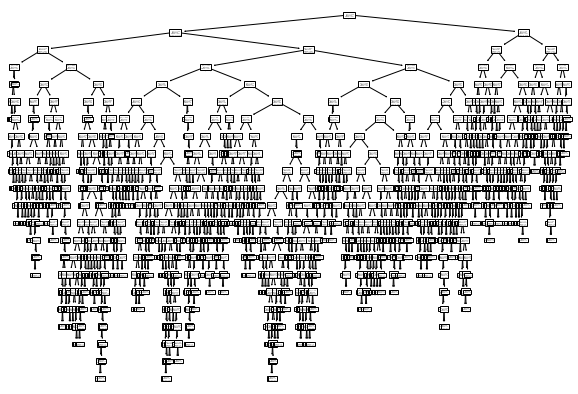

In [18]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(10, 7))
plot_tree(dt)
plt.show()

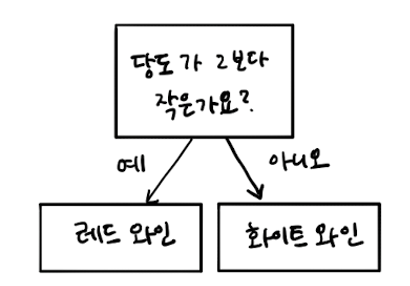

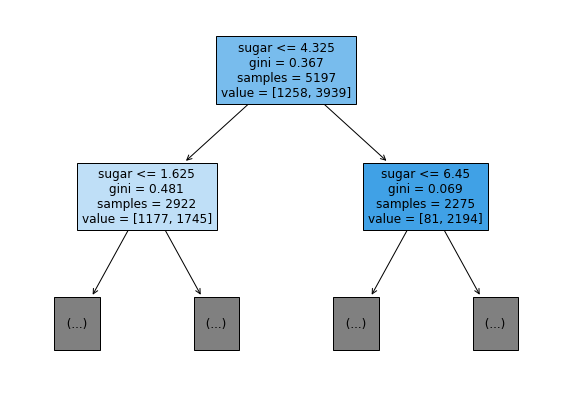

In [19]:
# max_depth=1은 root를 제외하여 1개 확장
# filled=True는 클래스에 맞게 색상을 칠한다
plt.figure(figsize=(10, 7))
plot_tree(dt, max_depth=1, filled=True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show()

```
테스트 조건(sugar)
불순도(gini)
총 샘플 수(samples)
클래스별 샘플 수(value)(음성 클래스, 양성 클래스)
```

##gini : 지니 불순도(Gini impurity)
       노드에 하나의 클래스만 있다면 지니 불순도는 0이된다(순수 노드)
       두 노드가 같은 비율이면 0.5가 된다(최악)
## 결정트리는 부모노드와 자식노드의 불순도 차이가 크도록 트리를 성장시킨다
   이 차이를 ```정보 이득(information gain)```

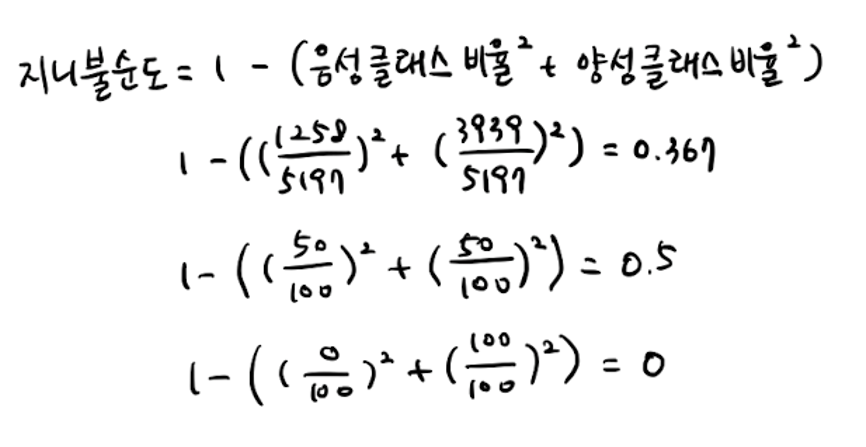

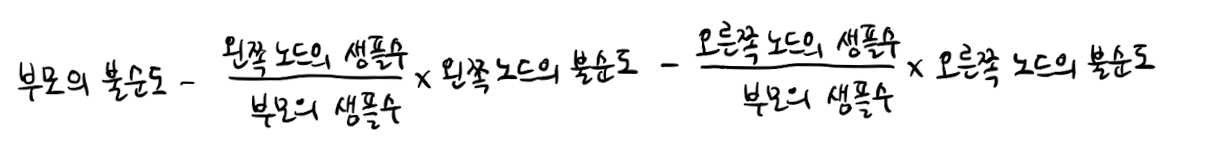

In [21]:
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(train_input, train_target)
print(dt.score(train_input, train_target))
print(dt.score(test_input, test_target))

0.8454877814123533
0.8415384615384616


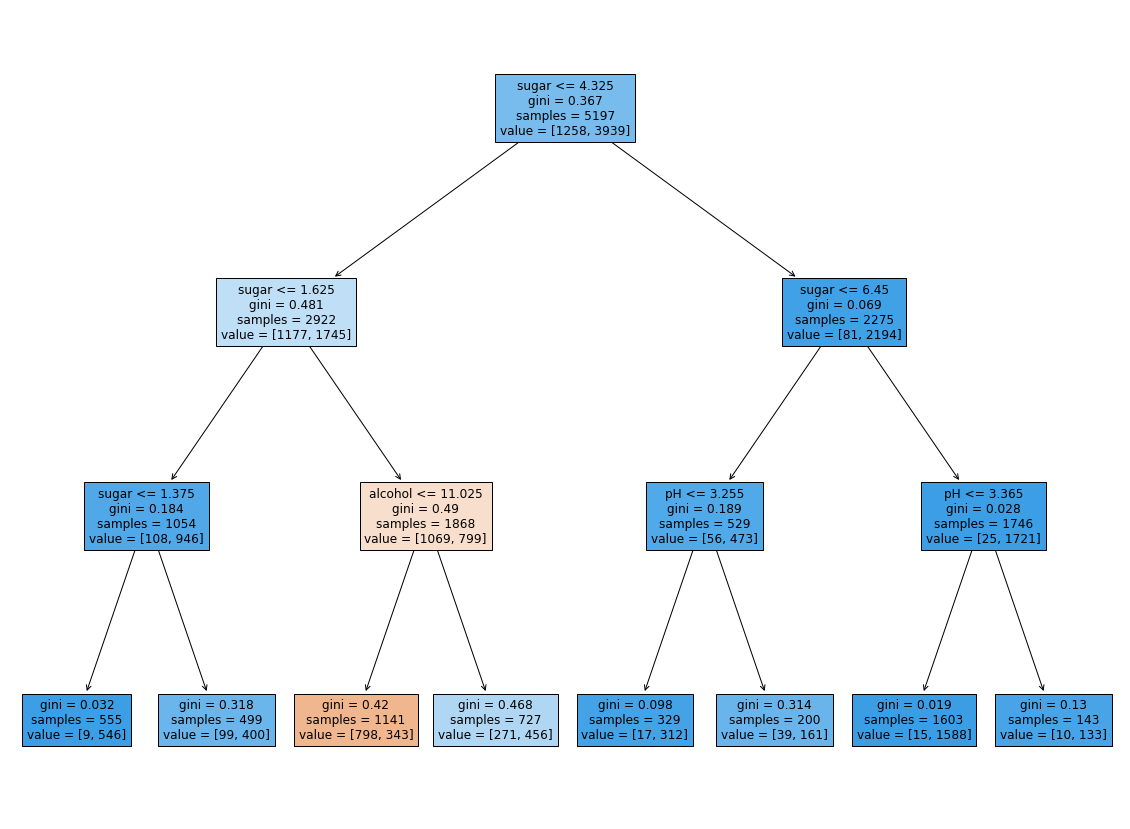

In [22]:
plt.figure(figsize=(20, 15))
plot_tree(dt, filled=True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show()